In [1]:
building = 1

# Setup

In [2]:
import torch
import pandas as pd

import Project.src.data.dataprep as prep
import Project.src.tensors.tensorisation as tensor

import matplotlib.pyplot as plt

def torch_py(torch_tensor):
    return torch_tensor.cpu().detach().numpy().flatten()

def rescale(values, scaler):
    rescaled_values = values * (scaler[1] - scaler[0]) + scaler[0]   
    return rescaled_values

In [3]:
nl_data = prep.dutch_data('../data/Dutchdata_clean/building_' + str(building) + '.parquet', 'h')

def assign_value(time, night, day):
    if time < pd.Timestamp("08:00:00").time() or time >= pd.Timestamp("19:00:00").time():
        return night
    else:
        return day

nl_data.loc[:,'offtake'] = nl_data.index.to_series().apply(lambda x: assign_value(x.time(),0.2,0.3))
nl_data.loc[:,'injection'] = nl_data.index.to_series().apply(lambda x: assign_value(x.time(),0.05,0.01))
nl_data['net_load'] = nl_data['load'] - nl_data['solar_energy']
nl_data['cost'] = nl_data.apply(lambda row: row['net_load'] * row['injection'] if row['net_load'] < 0 else row['net_load'] * row['offtake'], axis=1)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# Base parameters
T = 24
epochs = 500

# LSTM model

## Tensors

In [6]:
# Tensors for training
nl_tensors = tensor.Tensors(nl_data,'solar_energy',['solar_energy'],[],T,T)
X_train_base, X_test_base, y_train_base, y_test_base, scalers = nl_tensors.create_tensor()

y_train_base = y_train_base.unsqueeze(-1)
y_test_base = y_test_base.unsqueeze(-1)

## Model

In [7]:
import torch

In [8]:
src_var_size = 1
tgt_var_size = 1

src_seq_len = 24
tgt_seq_len = 24

n_heads = 8

In [9]:
import Project.src.models.transformer_encoder as tf

In [10]:
transformer = tf.build_transformer_model(src_var_size, src_seq_len, tgt_seq_len, dropout=0.1, d_model=48).to(device)

In [11]:
batch_size = 32

In [13]:
from Project.src.training.training_tf import Training

In [14]:
trainer = Training(transformer, X_train_base, y_train_base, X_test_base, y_test_base, None, None, epochs, encode_only=True, learning_rate=0.001)

Step 0: Average train loss: 0.4803 | Average test loss: 0.0473
Step 5: Average train loss: 0.0480 | Average test loss: 0.0220
Step 10: Average train loss: 0.0296 | Average test loss: 0.0353
Step 15: Average train loss: 0.0238 | Average test loss: 0.0326
Step 20: Average train loss: 0.0208 | Average test loss: 0.0280
Step 25: Average train loss: 0.0202 | Average test loss: 0.0283
Step 30: Average train loss: 0.0184 | Average test loss: 0.0279
Step 35: Average train loss: 0.0184 | Average test loss: 0.0257
Step 40: Average train loss: 0.0176 | Average test loss: 0.0236
Step 45: Average train loss: 0.0170 | Average test loss: 0.0244
Step 50: Average train loss: 0.0167 | Average test loss: 0.0234
Step 55: Average train loss: 0.0164 | Average test loss: 0.0228
Step 60: Average train loss: 0.0160 | Average test loss: 0.0219
Step 65: Average train loss: 0.0156 | Average test loss: 0.0210
Step 70: Average train loss: 0.0154 | Average test loss: 0.0194
Step 75: Average train loss: 0.0154 | Aver

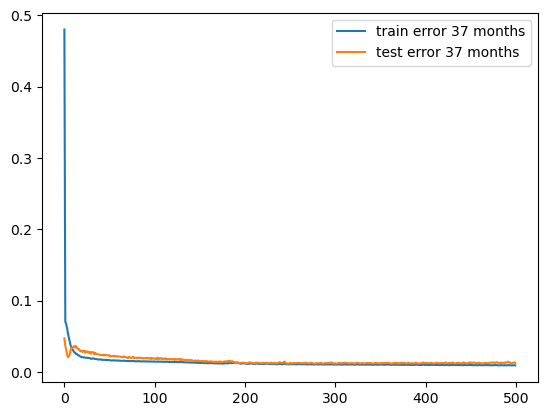

In [15]:
state_dict_list, argmin_test = trainer.fit()

In [16]:
transformer.load_state_dict(state_dict_list[argmin_test])

<All keys matched successfully>

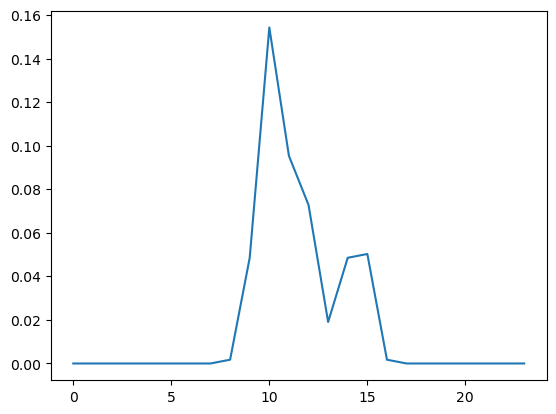

In [17]:
plt.plot(torch_py(y_test_base[0]))

In [24]:
prediction = transformer(X_test_base[0:6].to(device),None , None, None, encode_only=True)

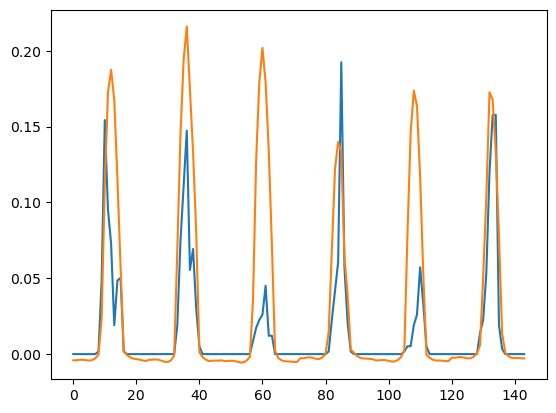

In [27]:
plt.plot(torch_py(y_test_base[0:6]))
plt.plot(torch_py(prediction))